In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import astropy.table as table
from astropy.io import ascii

from astropy import units as u

import astropy.coordinates as coord

In [2]:
plt.style.use('../code/std.mplstyle')
import matplotlib as mp
mp.rcParams['text.usetex'] = True

In [3]:
from galpy.potential import MWPotential2014, vesc 

In [4]:
## loads the current catalog from the release page 
## get release version
version_number_string = table.Table.read('https://raw.githubusercontent.com/apace7/local_volume_database/main/code/release_version.txt', format='ascii.fast_no_header')['col1'][0]
print("verion", version_number_string)
## load combined table
comb_all = table.Table.read('https://github.com/apace7/local_volume_database/releases/download/'+version_number_string+'/comb_all.csv')
dsph_mw = comb_all[comb_all['table'] == 'dwarf_mw']
dsph_m31 = comb_all[comb_all['table'] == 'dwarf_m31']
dsph_lf = comb_all[comb_all['table'] == 'dwarf_local_field']
ufsc = comb_all[comb_all['table'] == 'gc_ambiguous']
gc_disk = comb_all[comb_all['table'] == 'gc_mw_new']
gc_harris = comb_all[comb_all['table'] == 'gc_harris']

print(len(dsph_mw), len(dsph_m31), len(dsph_lf), len(ufsc), len(gc_disk), len(gc_harris))


verion v1.0.6
65 42 64 25 53 155


In [ ]:
## load local version of catalog
## creating the comb_all.csv catalog file will require running the combination scripts (./create_database.sh)
comb_all_local = table.Table.read('../data/comb_all.csv')
dsph_mw = comb_all_local[comb_all_local['table'] == 'dwarf_mw']
dsph_m31 = comb_all_local[comb_all_local['table'] == 'dwarf_m31']
dsph_lf = comb_all_local[comb_all_local['table'] == 'dwarf_local_field']
dsph_lf_distant = comb_all_local[comb_all_local['table'] == 'dwarf_local_field_distant']
ufsc = comb_all_local[comb_all_local['table'] == 'gc_ambiguous']
gc_disk = comb_all_local[comb_all_local['table'] == 'gc_mw_new']
gc_harris = comb_all_local[comb_all_local['table'] == 'gc_harris']


dsph_mw = MW dwarf galaxies (most distant is Eridanus 2)

dsph_m31 = M31 dwarf galaxies, two And 18 and And 28 are possible local field dwarfs

dsph_lf = Local field dwarf galaxies (D ~< 3 Mpc)

ufsc = ultra-faint star clusters, possible star clusters found after Harris catalog in the Galactic halo (|b|>10 deg), Koposov 1 and 2 are included but are in the Harris 2010 catalog, many of these objects are 
Some of these objects might be low mass dwarf galaxies

gc_disk = new globular clusters (post-Harris catalog) at low Galactic latitude (|b|<10 deg)
some of these objects might be open clusters

gc_harris = globular clusters in Harris catalog (excluding Koposov 1 and 2 which are in ufsc)

In [5]:
## M_V -> L_V
def lum(m_x, m_x_sun=4.83):
    return pow(10., -0.4*(m_x - m_x_sun) )

In [6]:
dsph_mw['mass_dynamical'] = dsph_mw['vlos_sigma']**2*930*dsph_mw['rhalf']*np.sqrt(1.-dsph_mw['ellipticity'])* dsph_mw['distance']*np.pi/180./60.*1000.
dsph_mw['mass_dynamical_ul'] = dsph_mw['vlos_sigma_ul']**2*930*dsph_mw['rhalf']*np.sqrt(1.-dsph_mw['ellipticity'])* dsph_mw['distance']*np.pi/180./60.*1000.


In [7]:
dsph_mw['mass_HI_ul'] = 235600*dsph_mw['flux_HI_ul']*(dsph_mw['distance']/1000.)**2

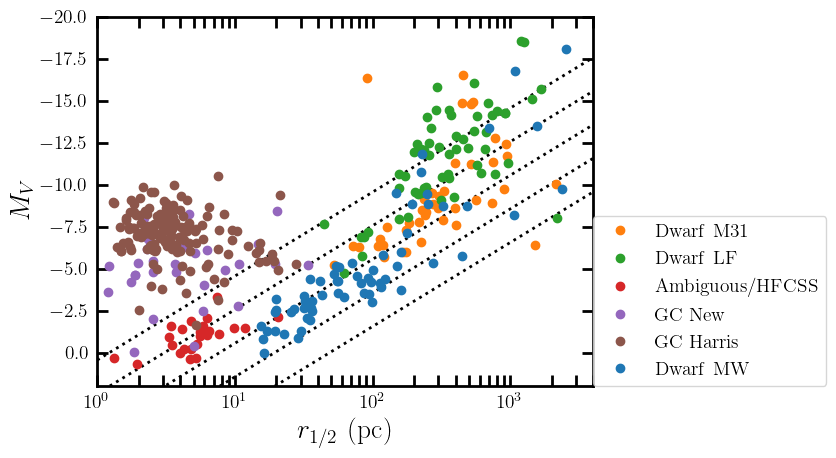

In [8]:
## size-luminosity plots
## add lines of constant surface brightness
def const_mu(muV, rhalf):
     return muV - 36.57 - 2.5 * np.log10(2.*np.pi*rhalf**2)
x = np.arange(1, 1e4, 1)
for mu in [24, 26, 28, 30, 32]:
    plt.plot(x,  [const_mu(mu, i/1000.) for i in x], c='k', lw=2, ls=':')

## plot data
plt.errorbar(dsph_mw['rhalf_sph_physical'], dsph_mw['M_V'], fmt='o', label=r'${\rm Dwarf~MW}$', )
plt.plot(dsph_m31['rhalf_sph_physical'], dsph_m31['M_V'], 'o', label=r'${\rm Dwarf~M31}$')
plt.plot(dsph_lf['rhalf_sph_physical'],dsph_lf['M_V'], 'o', label=r'${\rm Dwarf~LF}$')
plt.plot(ufsc['rhalf_sph_physical'], ufsc['M_V'], 'o',label=r'${\rm Ambiguous/HFCSS}$')
plt.plot(gc_disk['rhalf_sph_physical'], gc_disk['M_V'], 'o',label=r'${\rm GC~New}$')
plt.plot(gc_harris['rhalf_sph_physical'], gc_harris['M_V'], 'o',label=r'${\rm GC~Harris}$')
plt.gca().set_xscale('log')
plt.gca().invert_yaxis()
plt.gca().set_xlabel(r'$r_{1/2}~({\rm pc})$')
plt.gca().set_ylabel(r'$M_V$')
plt.legend(loc=(1,0))
plt.ylim(2, -20)
plt.xlim(1, 4e3)
plt.show()

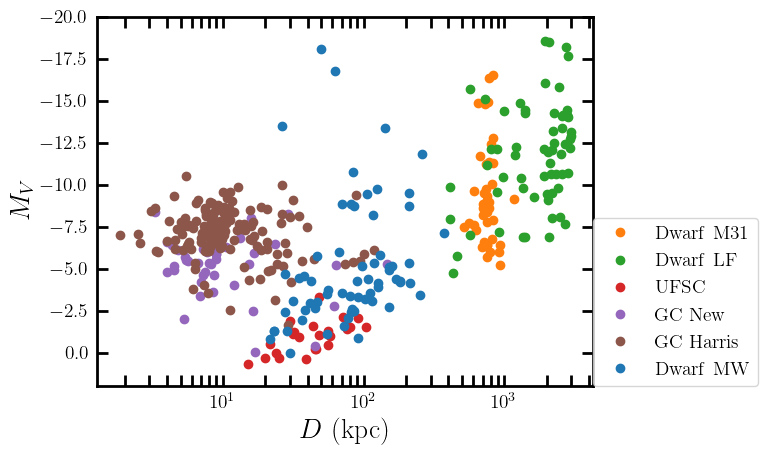

In [9]:
## distance-luminosity plots
plt.errorbar(dsph_mw['distance'], dsph_mw['M_V'], fmt='o', label=r'${\rm Dwarf~MW}$', )
plt.plot(dsph_m31['distance'], dsph_m31['M_V'], 'o', label=r'${\rm Dwarf~M31}$')
plt.plot(dsph_lf['distance'],dsph_lf['M_V'], 'o', label=r'${\rm Dwarf~LF}$')
plt.plot(ufsc['distance'], ufsc['M_V'], 'o',label=r'${\rm UFSC}$')
plt.plot(gc_disk['distance'], gc_disk['M_V'], 'o',label=r'${\rm GC~New}$')
plt.plot(gc_harris['distance'], gc_harris['M_V'], 'o',label=r'${\rm GC~Harris}$')
plt.gca().set_xscale('log')
plt.gca().invert_yaxis()
plt.gca().set_xlabel(r'$D~({\rm kpc})$')
plt.gca().set_ylabel(r'$M_V$')
plt.legend(loc=(1,0))
plt.ylim(2, -20)
plt.show()

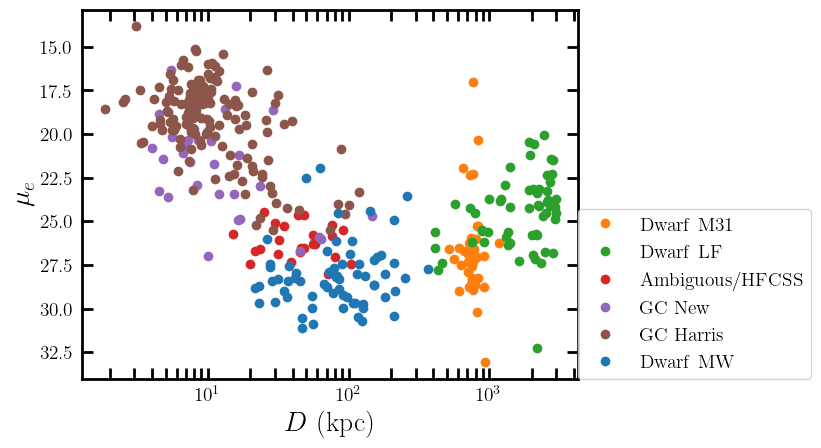

In [10]:
## distance versus average surface brightness
plt.errorbar(dsph_mw['distance'], dsph_mw['surface_brightness_rhalf'], fmt='o', label=r'${\rm Dwarf~MW}$', )
plt.plot(dsph_m31['distance'], dsph_m31['surface_brightness_rhalf'], 'o', label=r'${\rm Dwarf~M31}$')
plt.plot(dsph_lf['distance'],dsph_lf['surface_brightness_rhalf'], 'o', label=r'${\rm Dwarf~LF}$')
plt.plot(ufsc['distance'], ufsc['surface_brightness_rhalf'], 'o',label=r'${\rm Ambiguous/HFCSS}$')
plt.plot(gc_disk['distance'], gc_disk['surface_brightness_rhalf'], 'o',label=r'${\rm GC~New}$')
plt.plot(gc_harris['distance'], gc_harris['surface_brightness_rhalf'], 'o',label=r'${\rm GC~Harris}$')
plt.gca().set_xscale('log')
plt.gca().invert_yaxis()
plt.gca().set_xlabel(r'$D~({\rm kpc})$')
plt.gca().set_ylabel(r'$\mu_e$')
plt.legend(loc=(1,0))
# plt.ylim(2, -20)

plt.show()

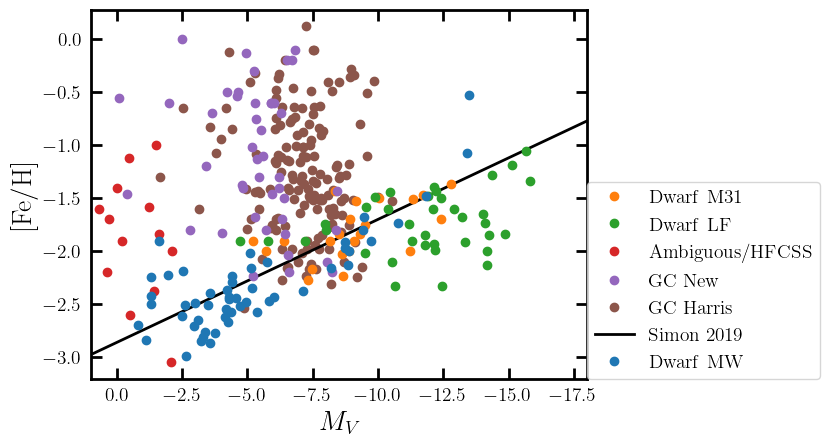

In [11]:
## mass/luminosity- metallicity 
plt.errorbar(dsph_mw['M_V'], dsph_mw['metallicity'], fmt='o', label=r'${\rm Dwarf~MW}$',zorder=100)
plt.plot(dsph_m31['M_V'], dsph_m31['metallicity'], 'o', label=r'${\rm Dwarf~M31}$')
plt.plot(dsph_lf['M_V'],dsph_lf['metallicity'], 'o', label=r'${\rm Dwarf~LF}$')
plt.plot(ufsc['M_V'], ufsc['metallicity'], 'o',label=r'${\rm Ambiguous/HFCSS}$', zorder=3)
plt.plot(gc_disk['M_V'], gc_disk['metallicity'], 'o',label=r'${\rm GC~New}$', zorder=2)
plt.plot(gc_harris['M_V'], gc_harris['metallicity'], 'o',label=r'${\rm GC~Harris}$', zorder=1)

plt.gca().invert_xaxis()
plt.gca().set_ylabel(r'${\rm [Fe/H]}$')
## luminoisty-metallicity relation from Simon 2019
## https://ui.adsabs.harvard.edu/abs/2019ARA%26A..57..375S/abstract
x = np.arange( -20,1, .1)
plt.plot(x,-1.68 + 0.29 * np.log10(lum(x)/1e6), c='k', lw=2, label=r'${\rm Simon~2019}$', zorder=1)
plt.gca().set_xlabel(r'$M_V$')
plt.legend(loc=(1,0))
plt.xlim(1, -18)
# plt.
plt.show()

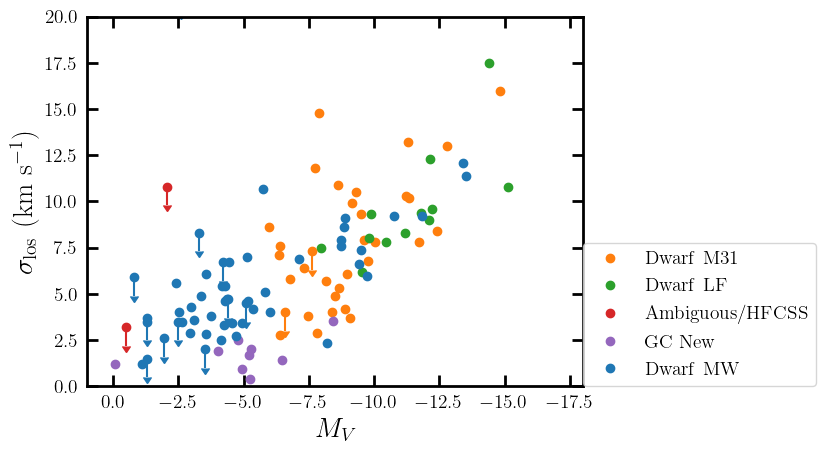

In [12]:
## MV vs velocity dispersion
plt.errorbar(dsph_mw['M_V'], dsph_mw['vlos_sigma'], fmt='o', label=r'${\rm Dwarf~MW}$', )

plt.errorbar(dsph_mw['M_V'], dsph_mw['vlos_sigma_ul'], fmt='o', yerr=np.ones(len(dsph_mw)), uplims=True, c='tab:blue' )
plt.plot(dsph_m31['M_V'], dsph_m31['vlos_sigma'], 'o', label=r'${\rm Dwarf~M31}$')
plt.errorbar(dsph_m31['M_V'], dsph_m31['vlos_sigma_ul'], fmt='o', yerr=np.ones(len(dsph_m31)), uplims=True, c='tab:orange' )
plt.plot(dsph_lf['M_V'],dsph_lf['vlos_sigma'], 'o', label=r'${\rm Dwarf~LF}$')
plt.plot(ufsc['M_V'], ufsc['vlos_sigma'], 'o',label=r'${\rm Ambiguous/HFCSS}$')
plt.errorbar(ufsc['M_V'], ufsc['vlos_sigma_ul'], fmt='o', yerr=np.ones(len(ufsc)), uplims=True, c='tab:red' )
plt.plot(gc_disk['M_V'], gc_disk['vlos_sigma'], 'o',label=r'${\rm GC~New}$')

# plt.gca().set_xscale('log')
plt.gca().invert_xaxis()
plt.gca().set_ylabel(r'$\sigma_{\rm los}~({\rm km~s^{-1}})$')
plt.gca().set_xlabel(r'$M_V$')
plt.legend(loc=(1,0))
plt.xlim(1, -18)
plt.ylim(0, 20)
plt.show()

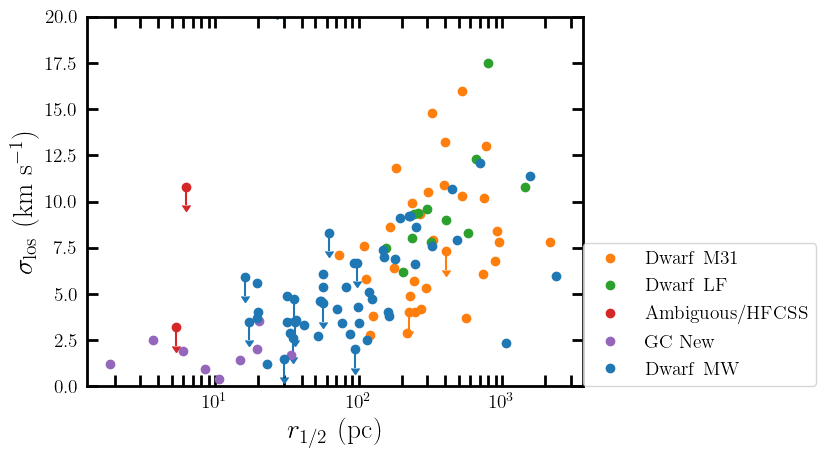

In [13]:
## size vs velocity dispersion
plt.errorbar(dsph_mw['rhalf_sph_physical'], dsph_mw['vlos_sigma'], fmt='o', label=r'${\rm Dwarf~MW}$', )
plt.errorbar(dsph_mw['rhalf_sph_physical'], dsph_mw['vlos_sigma_ul'], fmt='o', yerr=np.ones(len(dsph_mw)), uplims=True, c='tab:blue' )
plt.plot(dsph_m31['rhalf_sph_physical'], dsph_m31['vlos_sigma'], 'o', label=r'${\rm Dwarf~M31}$')
plt.errorbar(dsph_m31['rhalf_sph_physical'], dsph_m31['vlos_sigma_ul'], fmt='o', yerr=np.ones(len(dsph_m31)), uplims=True, c='tab:orange' )
plt.plot(dsph_lf['rhalf_sph_physical'],dsph_lf['vlos_sigma'], 'o', label=r'${\rm Dwarf~LF}$')
plt.plot(ufsc['rhalf_sph_physical'], ufsc['vlos_sigma'], 'o',label=r'${\rm Ambiguous/HFCSS}$')
plt.errorbar(ufsc['rhalf_sph_physical'], ufsc['vlos_sigma_ul'], fmt='o', yerr=np.ones(len(ufsc)), uplims=True, c='tab:red' )
plt.plot(gc_disk['rhalf_sph_physical'], gc_disk['vlos_sigma'], 'o',label=r'${\rm GC~New}$')
plt.gca().set_xscale('log')
plt.gca().set_ylabel(r'$\sigma_{\rm los}~({\rm km~s^{-1}})$')
plt.gca().set_xlabel(r'$r_{1/2}~({\rm pc})$')
plt.legend(loc=(1,0))
# plt.xlim(2, -18)
plt.ylim(0, 20)
plt.show()

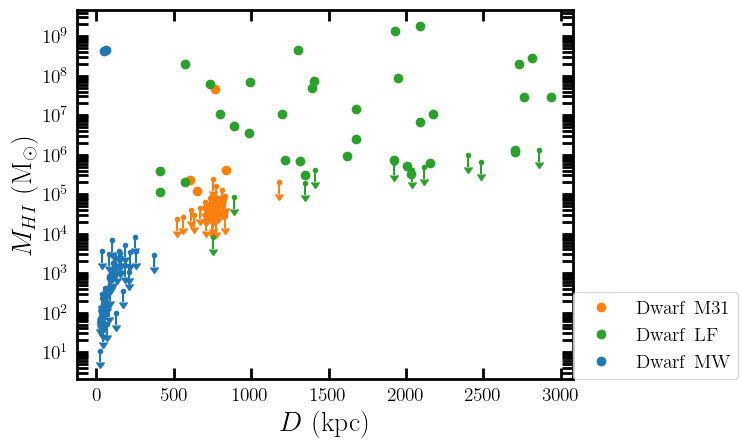

In [14]:
plt.errorbar(dsph_mw['distance'], 10**dsph_mw['mass_HI'], fmt='o', label=r'${\rm Dwarf~MW}$', )
plt.errorbar(dsph_mw['distance'], 235600*dsph_mw['flux_HI_ul']*(dsph_mw['distance']/1000.)**2, fmt='.', yerr=235600*dsph_mw['flux_HI_ul']*(dsph_mw['distance']/1000.)**2/2., uplims=True, c='tab:blue' )

plt.plot(dsph_m31['distance'], 10**dsph_m31['mass_HI'], 'o', label=r'${\rm Dwarf~M31}$')
plt.errorbar(dsph_m31['distance'], 235600*dsph_m31['flux_HI_ul']*(dsph_m31['distance']/1000.)**2, fmt='.', yerr=235600*dsph_m31['flux_HI_ul']*(dsph_m31['distance']/1000.)**2/2, uplims=True, c='tab:orange' )
plt.plot(dsph_lf['distance'],10**dsph_lf['mass_HI'], 'o', label=r'${\rm Dwarf~LF}$')
plt.errorbar(dsph_lf['distance'], 235600*dsph_lf['flux_HI_ul']*(dsph_lf['distance']/1000.)**2, fmt='.', yerr=235600*dsph_lf['flux_HI_ul']*(dsph_lf['distance']/1000.)**2/2., uplims=True, c='tab:green' )

# plt.gca().set_xscale('log')
plt.gca().set_yscale('log')
# plt.gca().invert_xaxis()
plt.gca().set_ylabel(r'$M_{H I}~({\rm M_{\odot}})$')
plt.gca().set_xlabel(r'$D~({\rm kpc})$')
plt.legend(loc=(1,0))
# plt.xlim(2, -18)
# plt.ylim(0, 20)
plt.show()

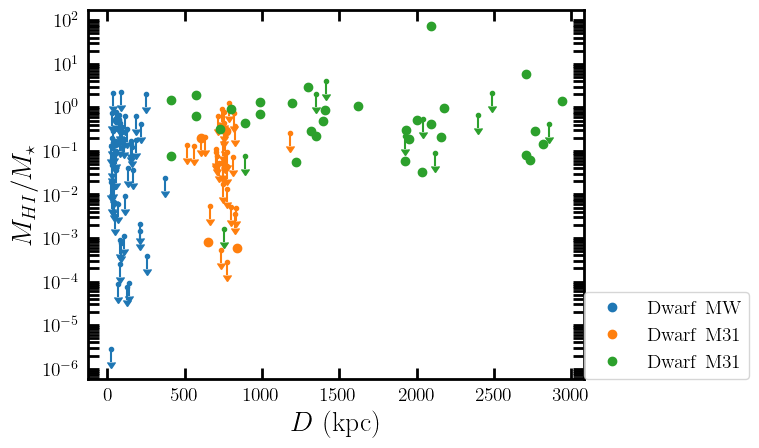

In [15]:
plt.errorbar(dsph_mw['distance'], 10**dsph_mw['mass_HI']/(2.*lum(dsph_mw['M_V'])), fmt='o', label=r'${\rm Dwarf~MW}$', )
plt.errorbar(dsph_mw['distance'], 235600*dsph_mw['flux_HI_ul']*(dsph_mw['distance']/1000.)**2/(2.*lum(dsph_mw['M_V'])), fmt='.', yerr=235600*dsph_mw['flux_HI_ul']*(dsph_mw['distance']/1000.)**2/2./(2.*lum(dsph_mw['M_V'])), uplims=True, c='tab:blue' )

plt.errorbar(dsph_m31['distance'], 10**dsph_m31['mass_HI']/(2.*lum(dsph_m31['M_V'])), fmt='o', label=r'${\rm Dwarf~M31}$',c='tab:orange' )
plt.errorbar(dsph_m31['distance'], 235600*dsph_m31['flux_HI_ul']*(dsph_m31['distance']/1000.)**2/(2.*lum(dsph_m31['M_V'])), fmt='.', yerr=235600*dsph_m31['flux_HI_ul']*(dsph_m31['distance']/1000.)**2/2./(2.*lum(dsph_m31['M_V'])), uplims=True, c='tab:orange' )

plt.errorbar(dsph_lf['distance'], 10**dsph_lf['mass_HI']/(2.*lum(dsph_lf['M_V'])), fmt='o', label=r'${\rm Dwarf~M31}$',c='tab:green' )
plt.errorbar(dsph_lf['distance'], 235600*dsph_lf['flux_HI_ul']*(dsph_lf['distance']/1000.)**2/(2.*lum(dsph_lf['M_V'])), fmt='.', yerr=235600*dsph_lf['flux_HI_ul']*(dsph_lf['distance']/1000.)**2/2./(2.*lum(dsph_lf['M_V'])), uplims=True, c='tab:green' )
plt.gca().set_yscale('log')
# plt.gca().invert_xaxis()
plt.gca().set_ylabel(r'$M_{H I}/M_{\star}$')
plt.gca().set_xlabel(r'$D~({\rm kpc})$')
plt.legend(loc=(1,0))
# plt.xlim(2, -18)
# plt.ylim(0, 20)
plt.show()

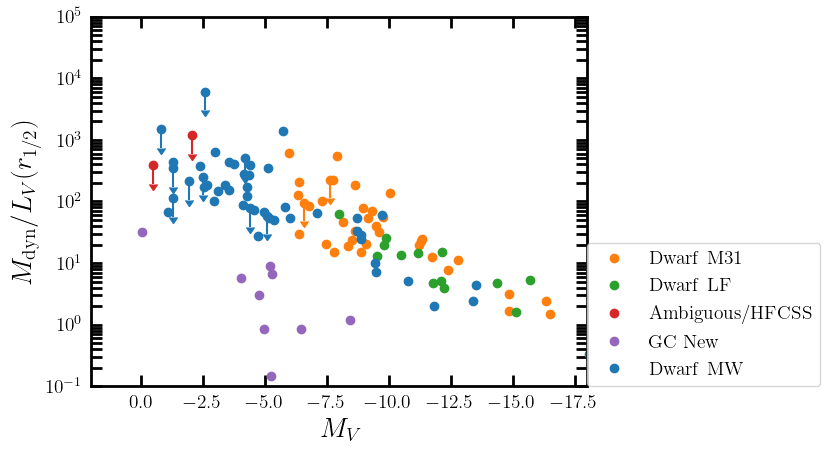

In [16]:
plt.errorbar(dsph_mw['M_V'], dsph_mw['mass_dynamical']/lum(dsph_mw['M_V'])/2., fmt='o', label=r'${\rm Dwarf~MW}$', )

plt.errorbar(dsph_mw['M_V'], dsph_mw['mass_dynamical_ul']/lum(dsph_mw['M_V'])/2., fmt='o', yerr= dsph_mw['mass_dynamical_ul']/lum(dsph_mw['M_V'])/2./2., uplims=True, c='tab:blue' )
plt.plot(dsph_m31['M_V'], dsph_m31['vlos_sigma']**2*930*dsph_m31['rhalf']*np.sqrt(1.-dsph_m31['ellipticity'])* dsph_m31['distance']*np.pi/180./60.*1000./lum(dsph_m31['M_V']), 'o', label=r'${\rm Dwarf~M31}$')
x = dsph_m31['vlos_sigma_ul']**2*930*dsph_m31['rhalf']*np.sqrt(1.-dsph_m31['ellipticity'])* dsph_m31['distance']*np.pi/180./60.*1000./lum(dsph_m31['M_V'])
plt.errorbar(dsph_m31['M_V'], x, fmt='o', yerr=x/2., uplims=True, c='tab:orange' )
plt.plot(dsph_lf['M_V'],dsph_lf['vlos_sigma']**2*930*dsph_lf['rhalf']*np.sqrt(1.-dsph_lf['ellipticity'])* dsph_lf['distance']*np.pi/180./60.*1000./lum(dsph_lf['M_V']), 'o', label=r'${\rm Dwarf~LF}$')
plt.plot(ufsc['M_V'], ufsc['vlos_sigma']**2*930*ufsc['rhalf']*np.sqrt(1.-ufsc['ellipticity'])* ufsc['distance']*np.pi/180./60.*1000./lum(ufsc['M_V']), 'o',label=r'${\rm Ambiguous/HFCSS}$')
x=ufsc['vlos_sigma_ul']**2*930*ufsc['rhalf']*np.sqrt(1.-ufsc['ellipticity'])* ufsc['distance']*np.pi/180./60.*1000./lum(ufsc['M_V'])
plt.errorbar(ufsc['M_V'], x, fmt='o', yerr=x/2, uplims=True, c='tab:red' )

plt.plot(gc_disk['M_V'], gc_disk['vlos_sigma']**2*930*gc_disk['rhalf']* gc_disk['distance']*np.pi/180./60.*1000./lum(gc_disk['M_V']), 'o',label=r'${\rm GC~New}$')

np.ones(len(dsph_mw))
plt.gca().set_yscale('log')
plt.gca().invert_xaxis()
plt.gca().set_ylabel(r'$M_{\rm dyn}/L_V(r_{1/2})$')

plt.gca().set_xlabel(r'$M_V$')
plt.legend(loc=(1,0))
plt.xlim(2, -18)
plt.ylim(.1, 1e5)
# plt.ylim(0, 20)
plt.show()

In [17]:
dis_name = table.Table.read("https://raw.githubusercontent.com/apace7/local_volume_database/main/old_data/name_discovery.csv")

In [18]:
year_dwarf_mw = dis_name[dis_name['table']=='dwarf_mw']
year_dwarf_m31 = dis_name[dis_name['table']=='dwarf_m31']
print(len(year_dwarf_mw), len(year_dwarf_m31))

60 39


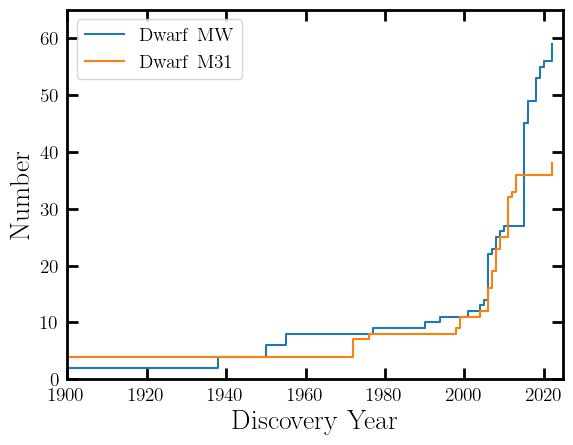

In [19]:
sorted_data = np.sort(year_dwarf_mw['discovery_year']) 
plt.step(sorted_data, np.arange(sorted_data.size), label=r'${\rm Dwarf~MW}$')  
sorted_data = np.sort(year_dwarf_m31['discovery_year']) 
plt.step(sorted_data, np.arange(sorted_data.size), label=r'${\rm Dwarf~M31}$')  
# plt.step(sorted_data[::-1], np.arange(sorted_data.size)/len(sorted_data))  
plt.xlim(1900, 2025)
plt.ylim(0, 65)
plt.legend(loc=2)
plt.xlabel(r'${\rm Discovery~Year}$')
plt.ylabel(r'${\rm Number}$')
plt.show()

In [20]:
coord.galactocentric_frame_defaults.set('v4.0')
gc_frame = coord.Galactocentric()

In [21]:
c_dsph_mw = coord.SkyCoord(ra=dsph_mw['ra']*u.deg, dec=dsph_mw['dec']*u.deg,  frame='icrs', 
                      distance=dsph_mw['distance']*u.kpc, radial_velocity=dsph_mw['vlos_systemic']*u.km/u.s, pm_ra_cosdec=dsph_mw['pmra']*u.mas/u.yr,pm_dec=dsph_mw['pmdec']*u.mas/u.yr)
c_dsph_m31 = coord.SkyCoord(ra=dsph_m31['ra']*u.deg, dec=dsph_m31['dec']*u.deg,  frame='icrs', 
                      distance=dsph_m31['distance']*u.kpc)
c_dsph_lf = coord.SkyCoord(ra=dsph_lf['ra']*u.deg, dec=dsph_lf['dec']*u.deg,  frame='icrs', 
                      distance=dsph_lf['distance']*u.kpc)
c_ufsc = coord.SkyCoord(ra=ufsc['ra']*u.deg, dec=ufsc['dec']*u.deg,  frame='icrs', 
                      distance=ufsc['distance']*u.kpc)
c_gc_disk = coord.SkyCoord(ra=gc_disk['ra']*u.deg, dec=gc_disk['dec']*u.deg,  frame='icrs', 
                      distance=gc_disk['distance']*u.kpc)
c_gc_harris = coord.SkyCoord(ra=gc_harris['ra']*u.deg, dec=gc_harris['dec']*u.deg,  frame='icrs', 
                      distance=gc_harris['distance']*u.kpc)

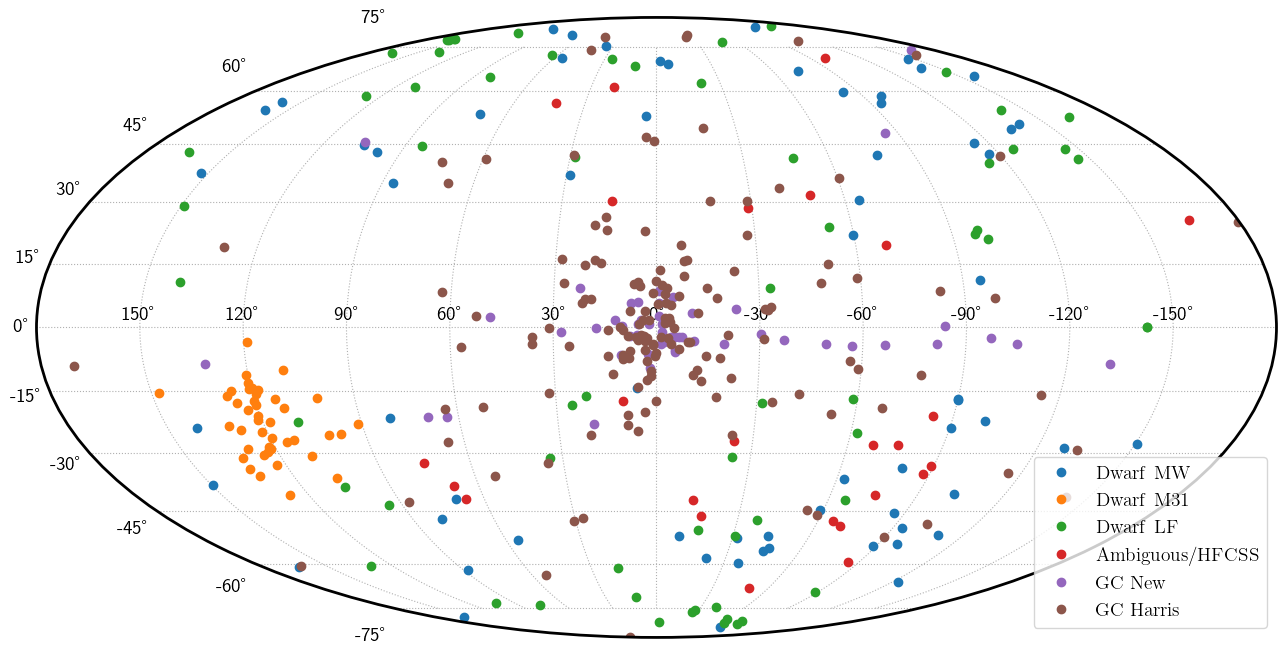

In [22]:
fig = plt.figure(1,figsize=(16,11))
ax = fig.add_subplot(111, projection='mollweide')
# flip the sign of longitude to match the standard astronomical convention
ax.plot(-c_dsph_mw.galactic.l.wrap_at(180*u.deg).rad, c_dsph_mw.galactic.b.rad  , 'o', label=r'${\rm Dwarf~MW}$')
ax.plot(-c_dsph_m31.galactic.l.wrap_at(180*u.deg).rad, c_dsph_m31.galactic.b.rad  , 'o', label=r'${\rm Dwarf~M31}$')
ax.plot(-c_dsph_lf.galactic.l.wrap_at(180*u.deg).rad, c_dsph_lf.galactic.b.rad  , 'o', label=r'${\rm Dwarf~LF}$')
ax.plot(-c_ufsc.galactic.l.wrap_at(180*u.deg).rad, c_ufsc.galactic.b.rad  , 'o', label=r'${\rm Ambiguous/HFCSS}$')
ax.plot(-c_gc_disk.galactic.l.wrap_at(180*u.deg).rad, c_gc_disk.galactic.b.rad  , 'o', label=r'${\rm GC~New}$')
ax.plot(-c_gc_harris.galactic.l.wrap_at(180*u.deg).rad, c_gc_harris.galactic.b.rad  , 'o', label=r'${\rm GC~Harris}$')
ax.set_xticklabels(ax.get_xticklabels()[::-1])  # sign flip for longitude labels
ax.grid(ls=':')
ax.legend(loc=4)

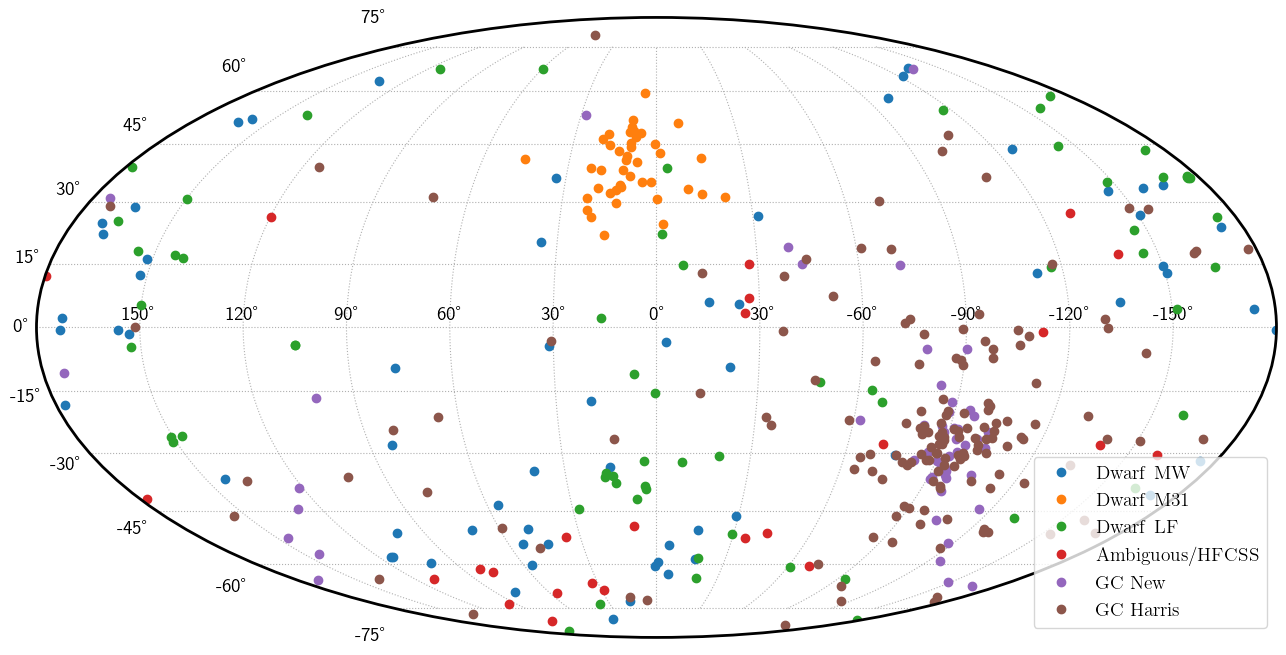

In [23]:
fig = plt.figure(1,figsize=(16,11))
ax = fig.add_subplot(111, projection='mollweide')
ax.plot(-c_dsph_mw.ra.wrap_at(180*u.deg).rad, c_dsph_mw.dec.rad  , 'o', label=r'${\rm Dwarf~MW}$')
ax.plot(-c_dsph_m31.ra.wrap_at(180*u.deg).rad, c_dsph_m31.dec.rad  , 'o', label=r'${\rm Dwarf~M31}$')
ax.plot(-c_dsph_lf.ra.wrap_at(180*u.deg).rad, c_dsph_lf.dec.rad  , 'o', label=r'${\rm Dwarf~LF}$')
ax.plot(-c_ufsc.ra.wrap_at(180*u.deg).rad, c_ufsc.dec.rad  , 'o', label=r'${\rm Ambiguous/HFCSS}$')
ax.plot(-c_gc_disk.ra.wrap_at(180*u.deg).rad, c_gc_disk.dec.rad  , 'o', label=r'${\rm GC~New}$')
ax.plot(-c_gc_harris.ra.wrap_at(180*u.deg).rad, c_gc_harris.dec.rad  , 'o', label=r'${\rm GC~Harris}$')
ax.set_xticklabels(ax.get_xticklabels()[::-1])
ax.grid(ls=':')
ax.legend(loc=4)

In [24]:
c_gc = c_dsph_mw.transform_to(gc_frame)
dsph_mw['distance_gc'] = np.sqrt(c_gc.cartesian.x.value**2 + c_gc.cartesian.y.value**2 + c_gc.cartesian.z.value**2) 

In [25]:
# c= coord.ICRS(ra=dsph_mw['ra']*u.deg, dec=dsph_mw['dec']*u.deg,  
#                       distance=dsph_mw['distance']*u.kpc, radial_velocity=dsph_mw['vlos_systemic']*u.km/u.s,)
# # def rv_to_gsr(c, v_sun=None):
gal = c_dsph_mw.transform_to(coord.Galactic)
cart_data = gal.data.to_cartesian()
unit_vector = cart_data / cart_data.norm()
v_sun = coord.Galactocentric().galcen_v_sun.to_cartesian()
v_proj = v_sun.dot(unit_vector)

dsph_mw['vel_gsr'] = c_dsph_mw.radial_velocity + v_proj 

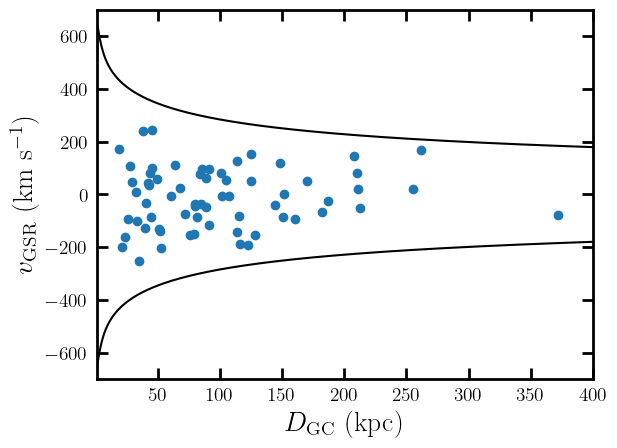

In [26]:
plt.plot(dsph_mw['distance_gc'], dsph_mw['vel_gsr'], 'o')
rad = np.arange(1,400,1)
plt.plot(rad, vesc(MWPotential2014,rad/8.)*220., c='k')
plt.plot(rad, -vesc(MWPotential2014,rad/8.)*220., c='k')
plt.xlim(1,400)
plt.ylim(-700,700)

plt.xlabel(r'$D_{\rm {\rm GC}}~({\rm kpc})$')
plt.ylabel(r'$v_{\rm {\rm GSR}}~({\rm km~s^{-1}})$')
plt.show()

In [27]:
v_sun = coord.CartesianDifferential([11.1,245.,7.25]*u.km/u.s)
gc_frame= coord.Galactocentric(galcen_distance=8.1*u.kpc,
                                   z_sun=25.*u.pc,
                                   galcen_v_sun=v_sun)
cg= c_dsph_mw.transform_to(gc_frame)
cg.representation_type= 'cylindrical'

dsph_mw['vel_3d'] = np.sqrt(cg.d_rho.to(u.km/u.s).value**2 + (cg.d_phi*cg.rho).to(u.km/u.s,        equivalencies=u.dimensionless_angles()).value**2 + cg.d_z.to(u.km/u.s).value**2)
dsph_mw['vel_rad'] = cg.d_rho.to(u.km/u.s).value

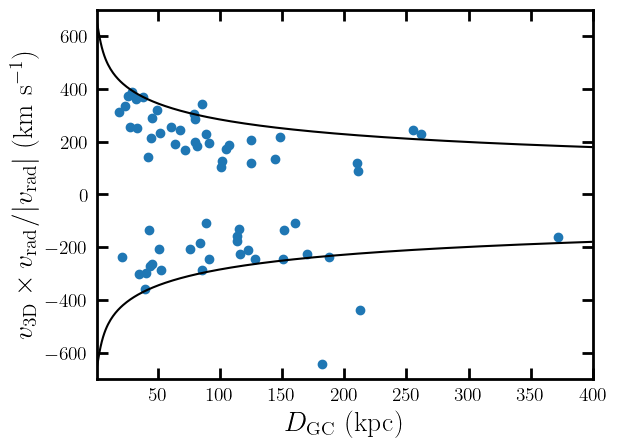

In [28]:
plt.ylabel(r'$v_{\rm {\rm 3D}}\times v_{\rm rad}/ | v_{\rm rad} |~({\rm km~s^{-1}})$')
plt.plot(dsph_mw['distance_gc'], dsph_mw['vel_rad']/abs(dsph_mw['vel_rad'])*dsph_mw['vel_3d'], 'o')
rad = np.arange(1,400,1)
plt.plot(rad, vesc(MWPotential2014,rad/8.)*220., c='k')
plt.plot(rad, -vesc(MWPotential2014,rad/8.)*220., c='k')
plt.xlim(1,400)
plt.ylim(-700,700)
plt.xlabel(r'$D_{\rm {\rm GC}}~({\rm kpc})$')
plt.show()